17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training RNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.7206 - loss: 0.5325 - val_accuracy: 0.7548 - val_loss: 0.4984
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.8232 - loss: 0.3995 - val_accuracy: 0.8044 - val_loss: 0.4388
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.9405 - loss: 0.1626 - val_accuracy: 0.8274 - val_loss: 0.4475
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.9922 - loss: 0.0357 - val_accuracy: 0.7872 - val_loss: 0.6055

Training LSTM...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 265ms/step - accuracy: 0.7567 - loss: 0.4830 - val_accuracy: 0.7558 - val_loss: 0.4907
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 277ms/step - accuracy: 0.8898 - loss: 0.2741 - val_accuracy: 0.8692 - val_loss: 0.3078
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 275ms/step - accuracy: 0.9207 - loss: 0.2049 - val_accuracy: 0.8574 - val_loss: 0.3677
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 280ms/step - accuracy: 0.9452 - loss: 0.148

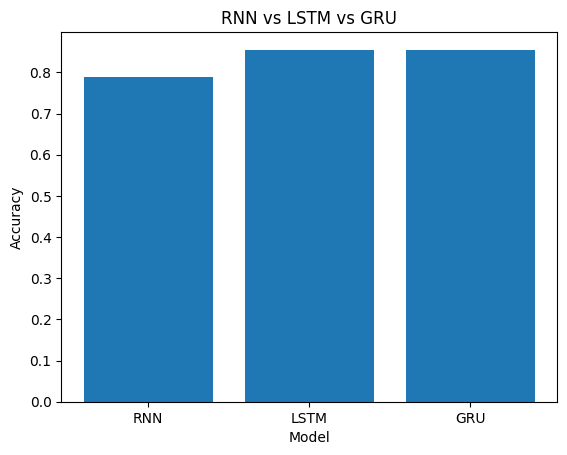

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import imdb

# 🔹 Load IMDB dataset automatically
max_words = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_words)

# 🔹 Padding
X_train_pad = pad_sequences(X_train, maxlen=max_len)
X_test_pad = pad_sequences(X_test, maxlen=max_len)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2)

# 🔹 Function to build models
def build_model(model_type):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

    if model_type == 'RNN':
        model.add(SimpleRNN(64))
    elif model_type == 'LSTM':
        model.add(LSTM(64))
    elif model_type == 'GRU':
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# 🔹 Train models
models = {}
histories = {}

for model_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\nTraining {model_type}...")
    model = build_model(model_type)

    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        epochs=5,
        batch_size=128,
        callbacks=[early_stop],
        verbose=1
    )

    models[model_type] = model
    histories[model_type] = history

# 🔹 Evaluate models
results = {}

for model_type, model in models.items():
    loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    results[model_type] = acc
    print(f"{model_type} Accuracy: {acc:.4f}")

# 🔹 Plot comparison
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU")
plt.show()